In [7]:
# installations for colab
!pip install fiftyone torch torchvision google

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 137.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 90.7 MB/s eta 0:00

## Data Import

In [8]:
# package fiftyone handles all file management for downloading automatically
import fiftyone.zoo as foz

my_classes = ["Coffee", "Ice cream", "Candy"]

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=my_classes,
    max_samples=2000,
    shuffle=True
)

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [9.0s elapsed, 0s remaining, 779.7Mb/s]       


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [9.0s elapsed, 0s remaining, 779.7Mb/s]       


...

INFO:fiftyone.zoo.datasets:Loading 'open-images-v7' split 'train'


 100% |███████████████| 2000/2000 [11.9s elapsed, 0s remaining, 143.3 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 2000/2000 [11.9s elapsed, 0s remaining, 143.3 samples/s]      


Dataset 'open-images-v7-train-2000' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-2000' created


In [9]:
# processing adapted from 00-project on moodle
# downloads and stores the data in a google drive folder
import fiftyone as fo
from fiftyone import ViewField as F
from google.colab import drive
import shutil
import os

dataset = dataset.filter_labels("ground_truth", F("label").is_in(my_classes))

export_dir = "/content/drive/MyDrive/project-2026"

# removing previous download if exists
if os.path.exists(export_dir):
    shutil.rmtree(export_dir)
    print("Cleared old export")

patches = dataset.to_patches("ground_truth")

drive.mount('/content/drive')

export_dir = "/content/drive/MyDrive/project-2026"

patches.export(export_dir=export_dir,
            dataset_type=fo.types.ImageClassificationDirectoryTree,
            label_field="ground_truth")

Mounted at /content/drive
Directory '/content/drive/MyDrive/project-2026' already exists; export will be merged with existing files


Detected an image classification exporter and a label field 'ground_truth' of type <class 'fiftyone.core.labels.Detection'>. Exporting image patches...


INFO:fiftyone.utils.data.exporters:Detected an image classification exporter and a label field 'ground_truth' of type <class 'fiftyone.core.labels.Detection'>. Exporting image patches...


 100% |███████████████| 3799/3799 [2.5m elapsed, 0s remaining, 39.9 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 3799/3799 [2.5m elapsed, 0s remaining, 39.9 samples/s]      


## Data Exploration

In [10]:
print(dataset.first())

<SampleView: {
    'id': '69d6783e7beb7174602c2fa1',
    'media_type': 'image',
    'filepath': '/root/fiftyone/open-images-v7/train/data/04f2a3461eb21a2b.jpg',
    'tags': ['train'],
    'metadata': None,
    'created_at': datetime.datetime(2026, 4, 8, 15, 46, 6, 320000),
    'last_modified_at': datetime.datetime(2026, 4, 8, 15, 46, 6, 320000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '69d6783e7beb7174602c2f9c',
                'attributes': {},
                'tags': [],
                'label': 'Coffee',
                'bounding_box': [0.133125, 0.0, 0.618125, 0.708333],
                'mask': None,
                'mask_path': None,
                'confidence': None,
                'index': None,
                'IsOccluded': True,
                'IsTruncated': True,
                'IsGroupOf': True,
                'IsDepiction': True,
                'IsInside': True,
            }>,
            <Detection: 

In [11]:
from collections import Counter

label_counts = Counter()

for sample in dataset:
    if sample.ground_truth is None:
        continue
    for det in sample.ground_truth.detections:
        if det.label in my_classes:
            label_counts[det.label] += 1

print("Label Distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Distribution:
Coffee: 1276
Candy: 1091
Ice cream: 1432


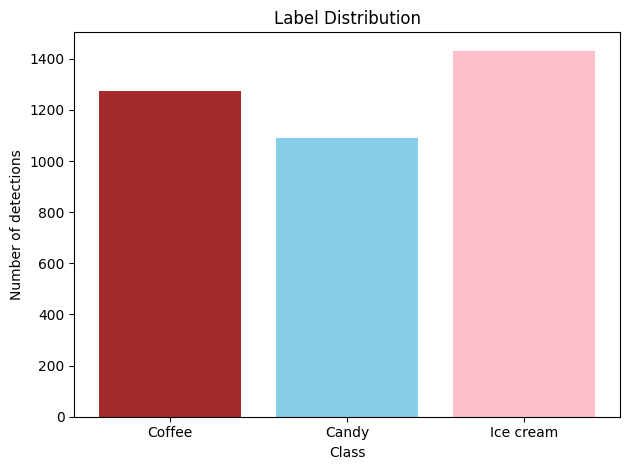

In [12]:
import matplotlib.pyplot as plt

plt.bar(label_counts.keys(), label_counts.values(), color=["brown", "skyblue", "pink"])
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of detections")
plt.tight_layout()
plt.show()

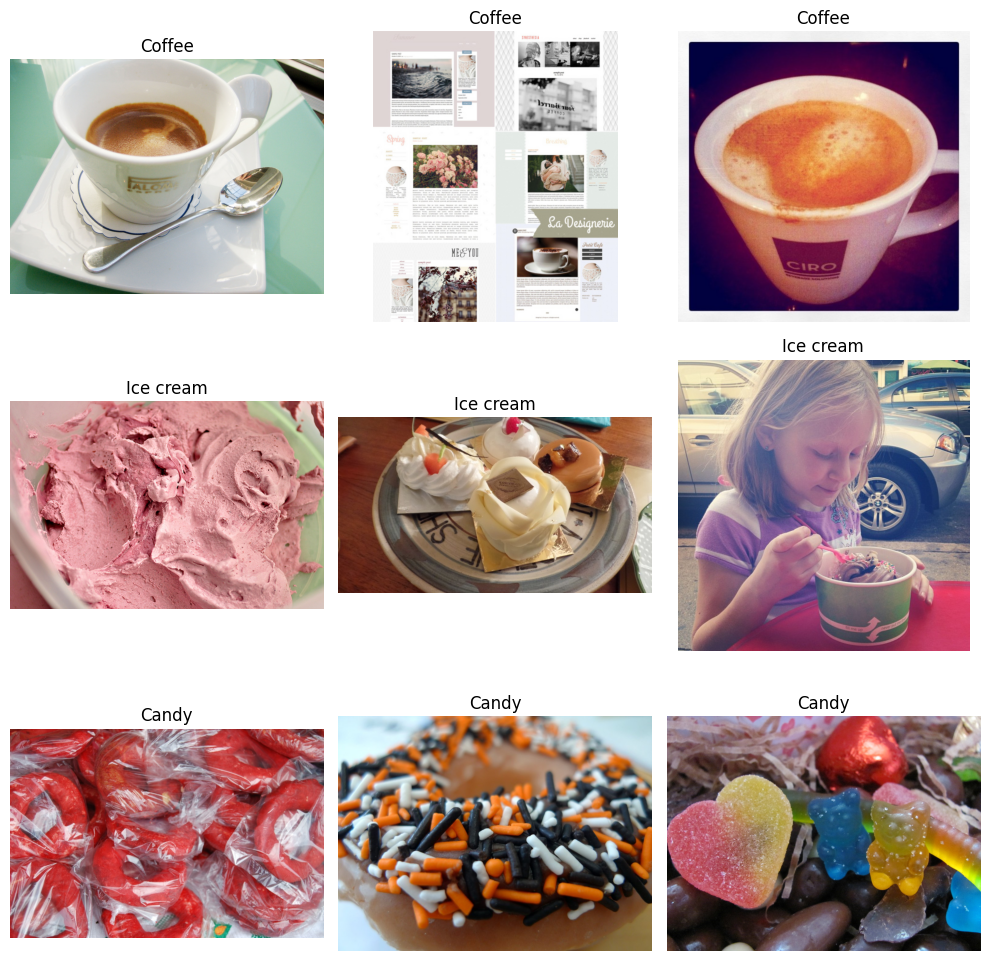

In [13]:
# looking at sample images per class
from PIL import Image

fig, axes = plt.subplots(len(my_classes), 3, figsize=(10, 10))

for row, cls in enumerate(my_classes):
    shown = 0
    for sample in dataset:
        if shown == 3:
            break
        if sample.ground_truth is None:
            continue
        labels = [d.label for d in sample.ground_truth.detections]
        if cls in labels:
            img = Image.open(sample.filepath).convert("RGB")
            axes[row, shown].imshow(img)
            axes[row, shown].set_title(cls)
            axes[row, shown].axis("off")
            shown += 1

plt.tight_layout()
plt.show()

Image Resolution Distribution:
Width - min: 505, max: 5456, mean: 968
Height - min: 303, max: 3672, mean: 846


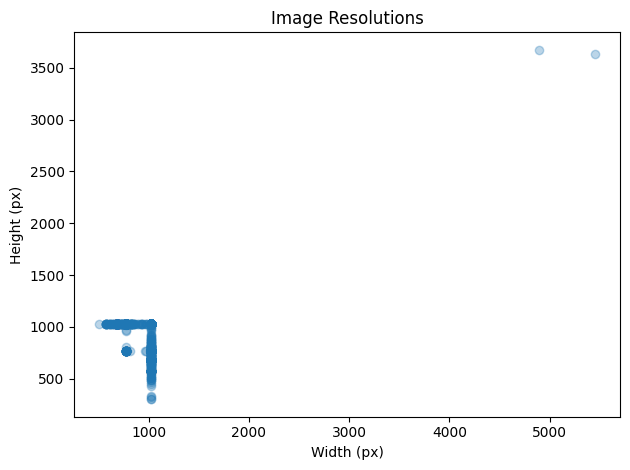

In [14]:
from PIL import Image
import numpy as np

widths_px, heights_px = [], []

for sample in dataset:
    with Image.open(sample.filepath) as img:
        w, h = img.size
        widths_px.append(w)
        heights_px.append(h)

print("Image Resolution Distribution:")
print(f"Width - min: {min(widths_px)}, max: {max(widths_px)}, mean: {np.mean(widths_px):.0f}")
print(f"Height - min: {min(heights_px)}, max: {max(heights_px)}, mean: {np.mean(heights_px):.0f}")

plt.scatter(widths_px, heights_px, alpha=0.3)
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Resolutions")
plt.tight_layout()
plt.show()

In [15]:
# looking at how "cluttered" the images are on average, could affect training/performance
import numpy as np

objects_per_image = []

for sample in dataset:
    if sample.ground_truth is None:
        continue
    count = sum(1 for det in sample.ground_truth.detections if det.label in my_classes)
    objects_per_image.append(count)

print("Analysis of objects per image:")
print(f"Average objects per image: {np.mean(objects_per_image):.2f}")
print(f"Max objects in one image: {max(objects_per_image)}")

Analysis of objects per image:
Average objects per image: 1.90
Max objects in one image: 135


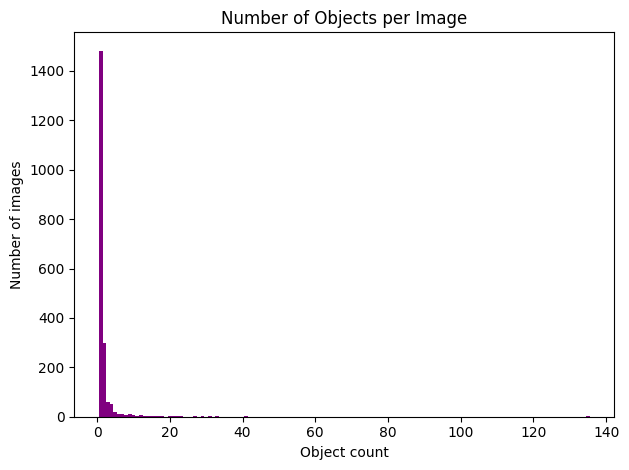

In [16]:
plt.hist(objects_per_image, bins=range(1, max(objects_per_image)+2), color="purple", align="left")
plt.title("Number of Objects per Image")
plt.xlabel("Object count")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

In [17]:
from PIL import Image

widths_px, heights_px = [], []

for sample in dataset:
    with Image.open(sample.filepath) as img:
        w, h = img.size
        widths_px.append(w)
        heights_px.append(h)

print("Image Resolution Distribution:")
print(f"Width  — min: {min(widths_px)}, max: {max(widths_px)}, mean: {np.mean(widths_px):.0f}")
print(f"Height — min: {min(heights_px)}, max: {max(heights_px)}, mean: {np.mean(heights_px):.0f}")

Image Resolution Distribution:
Width  — min: 505, max: 5456, mean: 968
Height — min: 303, max: 3672, mean: 846


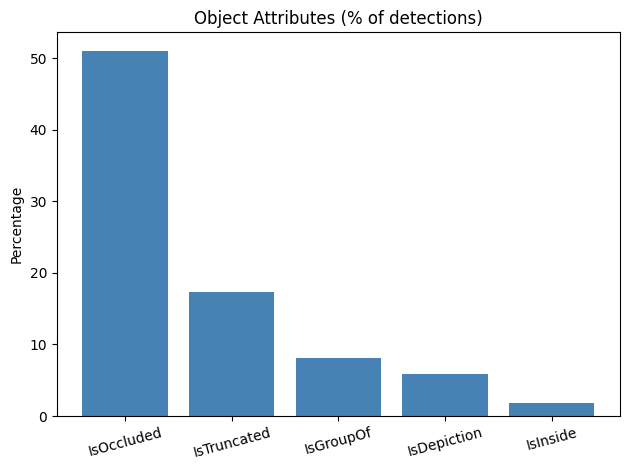

In [18]:
attributes = ["IsOccluded", "IsTruncated", "IsGroupOf", "IsDepiction", "IsInside"]

attr_counts = {attr: 0 for attr in attributes}
total = 0

for sample in dataset:
    if sample.ground_truth is None:
        continue
    for det in sample.ground_truth.detections:
        if det.label in my_classes:
            total += 1
            for attr in attributes:
                if getattr(det, attr, False):
                    attr_counts[attr] += 1

attr_pct = {k: v/total*100 for k, v in attr_counts.items()}

plt.bar(attr_pct.keys(), attr_pct.values(), color="steelblue")
plt.title("Object Attributes (% of detections)")
plt.ylabel("Percentage")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## VGG19-Network

In [19]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

In [20]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # VGG19 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# with augmentation
augment_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [21]:
# simplified loading following given
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

full_dataset = ImageFolder(root=export_dir, transform=base_transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(full_dataset.class_to_idx)

{'Candy': 0, 'Coffee': 1, 'Ice cream': 2}


In [22]:
def build_vgg19(pretrained=False, num_classes=3):
    weights = models.VGG19_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.vgg19(weights=weights)
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

model_scratch = build_vgg19(pretrained=False)
model_pretrained = build_vgg19(pretrained=True)   # for transfer learning experiment

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 97.6MB/s]


In [23]:
def train(model, loader, test_loader, epochs=10, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (out.argmax(1) == lbls).sum().item()
            total += lbls.size(0)

        train_acc = correct / total
        test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(total_loss / len(loader))
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return history

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
            total += lbls.size(0)
    return correct / total

## Comparing training base model vs transfer learning

In [28]:
print("Training from scratch:")
history_scratch = train(model_scratch, train_loader, test_loader, epochs=10)

print("Transfer learning:")
history_pretrained = train(model_pretrained, train_loader, test_loader, epochs=10)

Training from scratch:
Epoch 1/10 | Loss: 1.0064 | Train Acc: 0.4817 | Test Acc: 0.6421
Epoch 2/10 | Loss: 0.7594 | Train Acc: 0.6640 | Test Acc: 0.6618
Epoch 3/10 | Loss: 0.6593 | Train Acc: 0.7321 | Test Acc: 0.7276
Epoch 4/10 | Loss: 0.5836 | Train Acc: 0.7710 | Test Acc: 0.7618
Epoch 5/10 | Loss: 0.5161 | Train Acc: 0.7976 | Test Acc: 0.7711
Epoch 6/10 | Loss: 0.4756 | Train Acc: 0.8082 | Test Acc: 0.7750
Epoch 7/10 | Loss: 0.4194 | Train Acc: 0.8289 | Test Acc: 0.8118
Epoch 8/10 | Loss: 0.3766 | Train Acc: 0.8536 | Test Acc: 0.8013
Epoch 9/10 | Loss: 0.3400 | Train Acc: 0.8687 | Test Acc: 0.8105
Epoch 10/10 | Loss: 0.2922 | Train Acc: 0.8852 | Test Acc: 0.7934
Transfer learning:
Epoch 1/10 | Loss: 0.3775 | Train Acc: 0.8542 | Test Acc: 0.8487
Epoch 2/10 | Loss: 0.2370 | Train Acc: 0.9214 | Test Acc: 0.9276
Epoch 3/10 | Loss: 0.1522 | Train Acc: 0.9503 | Test Acc: 0.9303
Epoch 4/10 | Loss: 0.1705 | Train Acc: 0.9447 | Test Acc: 0.9237
Epoch 5/10 | Loss: 0.0865 | Train Acc: 0.9697 |

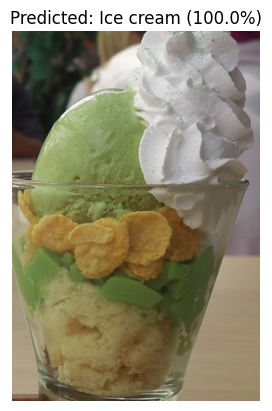

Candy: 0.0%
Coffee: 0.0%
Ice cream: 100.0%


In [33]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

# demonstration function for prediction that also prints image
def predict_image(model, image_path, transform):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()

    class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_idx]} ({probs[pred_idx]:.1%})")
    plt.axis("off")
    plt.show()

    for name, prob in zip(class_names, probs):
        print(f"{name}: {prob:.1%}")

test_image_path = test_dataset.dataset.samples[test_dataset.indices[0]][0]
predict_image(model_pretrained, test_image_path, base_transform)

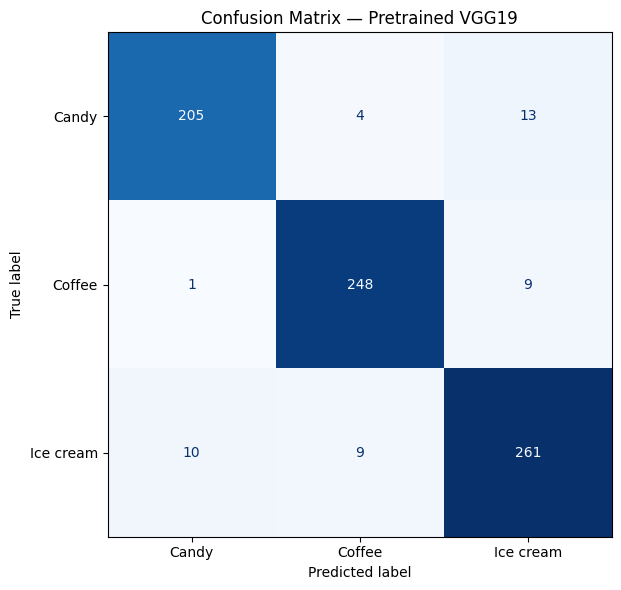

In [34]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix — Pretrained VGG19")
    plt.tight_layout()
    plt.show()

class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
plot_confusion_matrix(model_pretrained, test_loader, class_names)

## Experiments with Data Augmentation

In [24]:
# gleicher split, nur das training kriegt augmentation
from torch.utils.data import Subset

augmented_full_dataset = ImageFolder(root=export_dir, transform=augment_transform)

augmented_train_dataset = Subset(augmented_full_dataset, train_dataset.indices)
base_test_dataset = Subset(full_dataset, test_dataset.indices)

aug_train_loader = DataLoader(augmented_train_dataset, batch_size=16, shuffle=True)
aug_test_loader = DataLoader(base_test_dataset, batch_size=16, shuffle=False)

print(f"Train images mit augmentation: {len(augmented_train_dataset)}")
print(f"Test images ohne augmentation: {len(base_test_dataset)}")

Train images mit augmentation: 3039
Test images ohne augmentation: 760


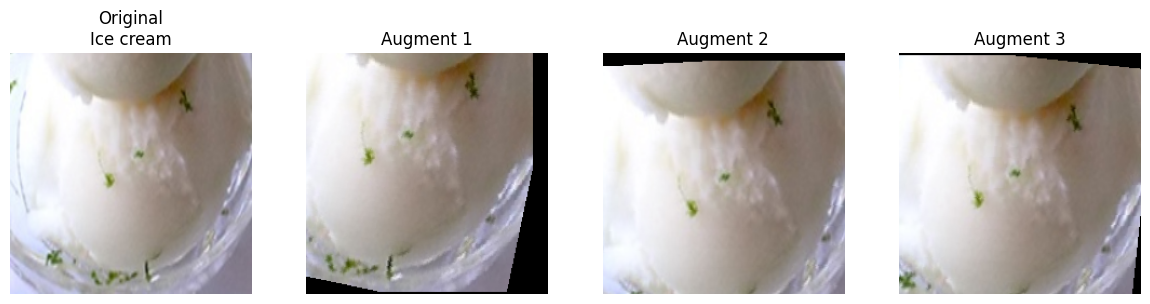

In [31]:
# kurze Bildprobe, damit man sieht was der Block macht
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_tensor_image(tensor, title):
    image = tensor.detach().cpu() * std + mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

sample_path, sample_label = full_dataset.samples[train_dataset.indices[0]]
sample_name = full_dataset.classes[sample_label]
sample_image = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
show_tensor_image(base_transform(sample_image), f"Original\n{sample_name}")

for i in range(3):
    plt.subplot(1, 4, i + 2)
    show_tensor_image(augment_transform(sample_image), f"Augment {i+1}")

plt.tight_layout()
plt.show()

In [26]:
print("Training pretrained VGG19 with augmentation:")
model_pretrained_aug = build_vgg19(pretrained=True)
history_pretrained_aug = train(model_pretrained_aug, aug_train_loader, aug_test_loader, epochs=10)

Training pretrained VGG19 with augmentation:
Epoch 1/10 | Loss: 0.4815 | Train Acc: 0.8269 | Test Acc: 0.8618
Epoch 2/10 | Loss: 0.2918 | Train Acc: 0.8963 | Test Acc: 0.9342
Epoch 3/10 | Loss: 0.2467 | Train Acc: 0.9095 | Test Acc: 0.9000
Epoch 4/10 | Loss: 0.2409 | Train Acc: 0.9098 | Test Acc: 0.8684
Epoch 5/10 | Loss: 0.2026 | Train Acc: 0.9253 | Test Acc: 0.9303
Epoch 6/10 | Loss: 0.1776 | Train Acc: 0.9408 | Test Acc: 0.9092
Epoch 7/10 | Loss: 0.1668 | Train Acc: 0.9401 | Test Acc: 0.9316
Epoch 8/10 | Loss: 0.1401 | Train Acc: 0.9529 | Test Acc: 0.9224
Epoch 9/10 | Loss: 0.1625 | Train Acc: 0.9464 | Test Acc: 0.9263
Epoch 10/10 | Loss: 0.1114 | Train Acc: 0.9592 | Test Acc: 0.9197


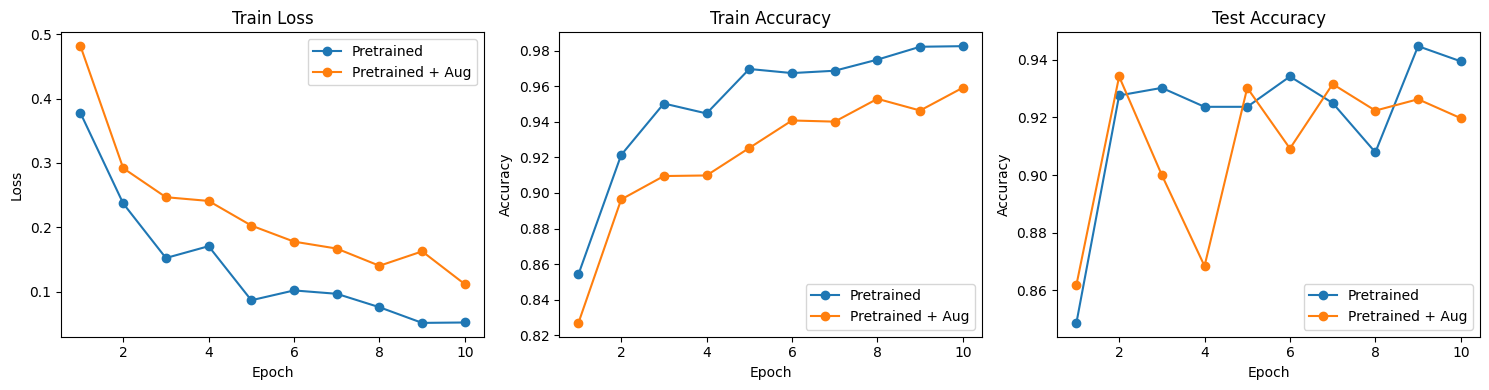

Beste Test Accuracy ohne Augmentation: 0.9447
Beste Test Accuracy mit Augmentation: 0.9342


In [29]:
epochs = range(1, len(history_pretrained["train_loss"]) + 1)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, history_pretrained["train_loss"], marker="o", label="Pretrained")
plt.plot(epochs, history_pretrained_aug["train_loss"], marker="o", label="Pretrained + Aug")
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, history_pretrained["train_acc"], marker="o", label="Pretrained")
plt.plot(epochs, history_pretrained_aug["train_acc"], marker="o", label="Pretrained + Aug")
plt.title("Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, history_pretrained["test_acc"], marker="o", label="Pretrained")
plt.plot(epochs, history_pretrained_aug["test_acc"], marker="o", label="Pretrained + Aug")
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Beste Test Accuracy ohne Augmentation: {max(history_pretrained['test_acc']):.4f}")
print(f"Beste Test Accuracy mit Augmentation: {max(history_pretrained_aug['test_acc']):.4f}")

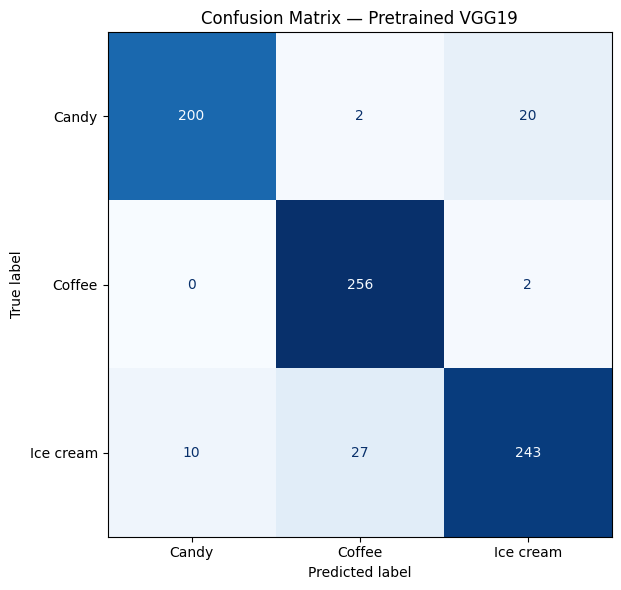

In [35]:
class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
plot_confusion_matrix(model_pretrained_aug, aug_test_loader, class_names)

## Experiments with Architecture

Rebuild VGG19. After layer block4_conv4 (32, 32,
512):
● Add the following bottleneck layer (padding same)
● Add conv layer (kernel 1x1, filters 1024, padding valid, stride 1, activation
leaky relu)
● Add conv layer (kernel 3x3, filters 1024, padding same, stride 1, activation
relu)
● Freeze conv3 layers and before
● Prediction head (Flatten and fully connected layers)